# Progressive Disclosure in Skill Loading

Context windows are finite. A production agent might have access to dozens of skills - each containing domain instructions, reference documents, scripts, and templates. Loading all of that content for every task would consume the context window before any real work could begin.

**Progressive disclosure** solves this with a tiered loading strategy:

| Tier | Content | When loaded | Typical cost |
|------|---------|------------|-------------|
| 1 — Metadata | YAML frontmatter only | Always (routing phase) | ~50–80 tokens per skill |
| 2 — Instructions | Full SKILL.md body | On skill activation | ~500–2,000 tokens (one skill) |
| 3 — Resources | `references/`, `scripts/`, `assets/` | On demand, mid-task | ~500–3,000 tokens per file |

In [1]:
import os
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Initializing the LLMs

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY", "").strip(), temperature=0)
print("Model ready:", llm.model)

# Token counting: tiktoken gives a fast, consistent estimate. It is OpenAI's tokenizer
try:
    import tiktoken
    _enc = tiktoken.encoding_for_model("gpt-4o")
    def count_tokens(text: str) -> int:
        return len(_enc.encode(text))
    print("Token counter: tiktoken (approximate)")
except ImportError:
    def count_tokens(text: str) -> int:
        return len(text) // 4  # ~4 chars per token for English
    print("Token counter: character estimate")

Model ready: gpt-4o-mini
Token counter: tiktoken (approximate)


## 1. The Context Budget Problem

Before implementing progressive disclosure, let's quantify the problem it solves. A naive agent that loads all skills upfront pays a steep context cost that scales with library size.

In [3]:
# Representative skill bodies — approximate real-world sizes
SAMPLE_SKILL_BODIES = {
    "code-review": """
# Code Review Skill
## When to use
Activate when asked to review, audit, or assess a code change or pull request.

## Review workflow
1. Read the entire change before forming any judgment
2. Classify each issue: CRITICAL / MAJOR / MINOR
3. For each issue: state line number, problem, and specific fix
4. Include a Strengths section and an OVERALL verdict

## Output format
CRITICAL ISSUES: (numbered list with line references and fixes)
MAJOR ISSUES: (numbered list)
MINOR ISSUES: (numbered list)
STRENGTHS: (bullet points)
OVERALL: (one sentence)
""",
    "git-commit-message": """
# Git Commit Message Skill
## When to use
Activate when asked to write, generate, or suggest a git commit message.

## Commit message protocol
Follow the Conventional Commits specification (conventionalcommits.org):
  <type>(<scope>): <description>

Types: feat, fix, docs, style, refactor, test, chore
Rules:
  - Subject line ≤ 72 characters
  - Use imperative mood: 'add' not 'added'
  - Body explains WHY, not WHAT (the diff shows what)
  - Footer for breaking changes: BREAKING CHANGE: <description>
""",
    "incident-response": """
# Incident Response Skill
## When to use
Activate during security incidents, outages, or production failures.

## Response phases
Phase 1 — TRIAGE (first 5 minutes):
  - Determine scope: how many users affected?
  - Determine severity: SEV1 (all users down) / SEV2 (partial) / SEV3 (degraded)
  - Page on-call if SEV1 or SEV2

Phase 2 — INVESTIGATION:
  - Collect logs from last 30 minutes before incident
  - Identify the first error in the timeline
  - Correlate with recent deployments

Phase 3 — MITIGATION:
  - Apply fastest available fix (rollback, feature flag, traffic shift)
  - Confirm resolution: check error rates and latency

Phase 4 — POST-INCIDENT:
  - Write incident report within 24 hours
  - Identify root cause and preventive action items
""",
    "legal-contract-review": """
# Legal Contract Review Skill
## When to use
Activate when asked to review, analyze, or summarize a legal contract, agreement, or MOU.

## Review workflow
1. Find governing law clause — record jurisdiction
2. Scan for liability provisions — flag uncapped or unlimited liability
3. Check IP ownership — flag work-for-hire and IP assignment clauses
4. Review termination terms — note notice periods and auto-renewal
5. Assess overall risk: LOW / MEDIUM / HIGH

## Important constraints
- Never provide legal advice — present findings and recommend counsel review
- Always cite specific clause numbers and section references
- Note if governing law is ambiguous as a separate risk factor
""",
    "data-analysis": """
# Data Analysis Skill
## When to use
Activate when asked to analyze, explore, or summarize a dataset or data file.

## Analysis workflow
1. Load and inspect: shape, dtypes, null counts, sample rows
2. Descriptive statistics: mean, median, std, min/max for numeric columns
3. Distribution analysis: identify skewed columns and outliers
4. Correlation: flag strongly correlated features (|r| > 0.8)
5. Key findings: top 3–5 insights in plain English
6. Recommendations: what to do next based on findings
""",
}

# Measure token cost of each skill body
print("Skill body token costs:")
total_naive = 0
for name, body in SAMPLE_SKILL_BODIES.items():
    tokens = count_tokens(body)
    total_naive += tokens
    print(f"  {name:<30} {tokens:>5} tokens")

print(f"\nNaive approach (load all upfront): {total_naive} tokens")
print(f"These 5 skills consume {total_naive} tokens before any work starts.")
print(f"At 20 skills (typical team): ~{total_naive * 4:,} tokens — before the task even begins.")

Skill body token costs:
  code-review                      144 tokens
  git-commit-message               124 tokens
  incident-response                190 tokens
  legal-contract-review            144 tokens
  data-analysis                    125 tokens

Naive approach (load all upfront): 727 tokens
These 5 skills consume 727 tokens before any work starts.
At 20 skills (typical team): ~2,908 tokens — before the task even begins.


Even with just five modest skills, naive loading consumes thousands of tokens before the agent processes a single word of the user's actual request. At scale this either overflows the context window or severely degrades reasoning quality by crowding out the task itself.

## Tier 1 - Skill metadata index
The first tier reads only the YAML frontmatter from each skill file. This compact representation contains everything the routing system needs: the skill's name, description (the routing signal), version, and allowed tools. The instruction body is never loaded during routing.

In [4]:
@dataclass
class SkillMetadata:
    """Compact skill record read during the discovery/routing phase (Tier 1)."""
    name: str
    description: str
    version: str
    allowed_tools: list[str]  # on disk this is the hyphenated `allowed-tools` YAML field
    tags: list[str] = field(default_factory=list)
    path: str = ""  # filesystem path to full SKILL.md

    def to_index_string(self) -> str:
        """Serialize only the routing-relevant fields — what the index actually stores."""
        return f"name: {self.name}\ndescription: {self.description}\ntags: {', '.join(self.tags)}"


# Build the skill index — this is what loads at startup, not the full bodies
SKILL_INDEX: list[SkillMetadata] = [
    SkillMetadata(
        name="code-review",
        description="Reviews code changes, pull requests, and diffs for correctness, security issues, and maintainability. Produces CRITICAL/MAJOR/MINOR severity-tiered reports.",
        version="1.0.0",
        allowed_tools=["read_file", "run_linter"],
        tags=["engineering", "quality", "review"],
        path="./example-skills/code-review/SKILL.md",
    ),
    SkillMetadata(
        name="git-commit-message",
        description="Generates conventional commit messages from staged diffs and change descriptions. Follows the Conventional Commits specification.",
        version="1.0.0",
        allowed_tools=["read_file"],
        tags=["engineering", "git", "commits"],
        path="./example-skills/git-commit-message/SKILL.md",
    ),
    SkillMetadata(
        name="incident-response",
        description="Guides through security incident triage, investigation, mitigation, and post-incident review. Handles outages and production failures with structured runbook procedures.",
        version="2.1.0",
        allowed_tools=["read_file", "search_web", "send_notification"],
        tags=["operations", "security", "incident", "oncall"],
        path="./example-skills/incident-response/SKILL.md",
    ),
    SkillMetadata(
        name="legal-contract-review",
        description="Reviews legal contracts, agreements, and MOUs for liability terms, IP clauses, governing law, and termination provisions.",
        version="1.0.0",
        allowed_tools=["read_file"],
        tags=["legal", "contracts", "compliance"],
        path="./skills/legal-contract-review/SKILL.md",
    ),
    SkillMetadata(
        name="data-analysis",
        description="Analyzes datasets and data files to produce descriptive statistics, distribution analysis, correlation findings, and actionable recommendations.",
        version="1.1.0",
        allowed_tools=["read_file", "execute_code"],
        tags=["data", "analysis", "statistics"],
        path="./skills/data-analysis/SKILL.md",
    ),
]

# Measure token cost of the index — only metadata strings
index_tokens_total = sum(count_tokens(s.to_index_string()) for s in SKILL_INDEX)
print("Tier 1 — Skill Index Token Costs:")
for s in SKILL_INDEX:
    idx_str = s.to_index_string()
    print(f"  {s.name:<30} {count_tokens(idx_str):>4} tokens")

print(f"\nTotal index cost ({len(SKILL_INDEX)} skills): {index_tokens_total} tokens")
print(f"vs. naive full load: {total_naive} tokens")
print(f"Savings at routing time: {total_naive - index_tokens_total} tokens ({(1 - index_tokens_total/total_naive)*100:.0f}% reduction)")

Tier 1 — Skill Index Token Costs:
  code-review                      49 tokens
  git-commit-message               36 tokens
  incident-response                45 tokens
  legal-contract-review            38 tokens
  data-analysis                    36 tokens

Total index cost (5 skills): 204 tokens
vs. naive full load: 727 tokens
Savings at routing time: 523 tokens (72% reduction)


The entire index - enough to route across five skills - costs far fewer tokens than loading a single skill body naively. This saving multiplies with library size: a 50-skill library still fits its index in a small fraction of what a naive full load would cost.

## Tier 2 - SKILL.md body on activation
Once routing selects a skill, Tier 2 loads the full instruction body. Only *one* skill's body enters context - not all of them. In a real filesystem-based implementation this reads the SKILL.md file; here we simulate with in-memory bodies.

In [5]:
def load_skill_body(skill: SkillMetadata) -> str:
    """Load the full SKILL.md instruction body for an activated skill (Tier 2).

    In production this reads the file at skill.path. Here we use in-memory
    bodies keyed by skill name.
    """
    return SAMPLE_SKILL_BODIES.get(skill.name, f"# {skill.name}\n\nSkill body not found.")


def check_token_budget(body: str, warn_at: int = 3000, hard_limit: int = 5000) -> dict:
    """Validate a skill body against token budget thresholds."""
    tokens = count_tokens(body)
    if tokens > hard_limit:
        status = "OVER LIMIT — move content to references/"
    elif tokens > warn_at:
        status = "WARNING — consider trimming or moving content"
    else:
        status = "OK"
    return {"tokens": tokens, "status": status}


# Demonstrate: activate the code-review skill after routing selects it
selected_skill = SKILL_INDEX[0]  # code-review
skill_body = load_skill_body(selected_skill)
budget = check_token_budget(skill_body)

print(f"Activated skill: {selected_skill.name}")
print(f"Allowed tools: {selected_skill.allowed_tools}")
print(f"Body token count: {budget['tokens']} — {budget['status']}")
print()
print("Skill body loaded into context:")
print("-" * 50)
print(skill_body)

Activated skill: code-review
Allowed tools: ['read_file', 'run_linter']
Body token count: 144 — OK

Skill body loaded into context:
--------------------------------------------------

# Code Review Skill
## When to use
Activate when asked to review, audit, or assess a code change or pull request.

## Review workflow
1. Read the entire change before forming any judgment
2. Classify each issue: CRITICAL / MAJOR / MINOR
3. For each issue: state line number, problem, and specific fix
4. Include a Strengths section and an OVERALL verdict

## Output format
CRITICAL ISSUES: (numbered list with line references and fixes)
MAJOR ISSUES: (numbered list)
MINOR ISSUES: (numbered list)
STRENGTHS: (bullet points)
OVERALL: (one sentence)



Two functions make up tier 2:
- **`load_skill_body`** fetches the full instruction text for the *one* skill routing selected. In production this is a file read at `skill.path`; here it pulls from the in-memory bodies so the notebook stays self-contained.
- **`check_token_budget`** guards skill size against a soft warning and a hard limit. The guidance for agent skills is to keep the always-activated body lean - when content grows past the budget it belongs in tier 3 resource files, not in the body that loads on every activation.

## Tier 3 - Resources on demand
Large reference documents, helper scripts, and templates live in subdirectories of the skill folder (`references/`, `scripts/`, `assets/`). They are never loaded at startup or activation - only when the agent's execution reaches a step that explicitly cites one.

The agent sees a reference like `references/review-checklist.md` in the skill body and loads it at that moment. If the task completes without reaching that step, the file never enters context.

In [6]:
# Mock resource files — in production these are real files on disk
MOCK_RESOURCES = {
    "code-review": {
        "references/review-checklist.md": """
# Code Review Checklist

## Correctness
- [ ] Does the logic match the stated intent?
- [ ] Are edge cases handled (empty input, null, zero)?
- [ ] Are return values used correctly by callers?

## Security
- [ ] No SQL built with string interpolation
- [ ] No eval(), exec(), or subprocess with user input
- [ ] Secrets not hardcoded in source
- [ ] Input validated at public API boundaries

## Performance
- [ ] No N+1 query patterns in loops
- [ ] Large collections not loaded into memory unnecessarily

## Maintainability
- [ ] Functions are focused (single responsibility)
- [ ] Variable names are descriptive
- [ ] No commented-out dead code
""",
        "assets/review-report-template.md": """
# Code Review Report

**Reviewer:** [agent]
**Date:** {{date}}
**File(s):** {{files}}

## CRITICAL ISSUES
{{critical_issues}}

## MAJOR ISSUES
{{major_issues}}

## MINOR ISSUES
{{minor_issues}}

## STRENGTHS
{{strengths}}

## OVERALL
{{overall}}
""",
    },
    "incident-response": {
        "references/escalation-matrix.md": """
# Escalation Matrix

| Severity | Response Time | First Contact | Escalation |
|----------|--------------|---------------|------------|
| SEV1 | 5 min | On-call + Engineering Lead | CTO at 15 min |
| SEV2 | 15 min | On-call | Engineering Lead at 30 min |
| SEV3 | 60 min | On-call | Engineering Lead at next day |
""",
    },
}


def load_resource(skill_name: str, resource_path: str) -> tuple[str, int]:
    """Load a specific resource file for an active skill (Tier 3).

    Returns (content, token_count). In production, reads from the filesystem.

    Args:
        skill_name: Name of the active skill.
        resource_path: Relative path like 'references/review-checklist.md'.
    """
    skill_resources = MOCK_RESOURCES.get(skill_name, {})
    content = skill_resources.get(resource_path, f"Resource not found: {resource_path}")
    return content, count_tokens(content)


# Demonstrate on-demand loading — only loads when the agent needs it
print("Tier 3 — Resource Loading (on demand)")
print("=" * 50)

resource_path = "references/review-checklist.md"
content, tokens = load_resource("code-review", resource_path)

print(f"Resource: {resource_path}")
print(f"Token cost when loaded: {tokens} tokens")
print(f"Token cost when NOT loaded: 0 tokens")
print()
print("Resource content:")
print(content[:400], "...")

Tier 3 — Resource Loading (on demand)
Resource: references/review-checklist.md
Token cost when loaded: 151 tokens
Token cost when NOT loaded: 0 tokens

Resource content:

# Code Review Checklist

## Correctness
- [ ] Does the logic match the stated intent?
- [ ] Are edge cases handled (empty input, null, zero)?
- [ ] Are return values used correctly by callers?

## Security
- [ ] No SQL built with string interpolation
- [ ] No eval(), exec(), or subprocess with user input
- [ ] Secrets not hardcoded in source
- [ ] Input validated at public API boundaries

## Perf ...


If the agent's task completes without needing the review checklist - for example, a very short diff with an obvious bug - the reference file never loads. Token cost for that resource: zero. This lazy evaluation pattern is what makes deep skill resource libraries practical.

## Routing: Matching queries to skills
The routing layer decides which skill matches the user's query using only the tier 1 metadata - never the bodies. Two strategies are practical in production: **LLM-based routing** (higher accuracy, costs one LLM call) and **embedding similarity** (fast, no LLM call). We build each in turn, then test both on natural phrasings.

In [7]:
# Strategy 1 — LLM-based routing.
# Show the model every skill's metadata and let it pick the best match by name.
# High accuracy and robust to paraphrasing, at the cost of one LLM call per query.

def route_with_llm(query: str, skill_index: list[SkillMetadata]) -> Optional[SkillMetadata]:
    """Select the best matching skill for a query using the LLM.

    Args:
        query: The user's task description.
        skill_index: Available skill metadata records (Tier 1 only).

    Returns:
        The matched SkillMetadata, or None if no skill fits.
    """
    # Build a numbered menu from name + description — the only fields the router needs
    skill_list = "\n".join(
        f"  {i+1}. {s.name}: {s.description}"
        for i, s in enumerate(skill_index)
    )

    # Constrain the model to reply with a single skill name (or 'none')
    prompt = f"""You are a skill router. Given a user query and a list of available skills,
select the single best matching skill. Reply with just the skill name (e.g. 'code-review').
If no skill fits, reply with 'none'.

Available skills:
{skill_list}

User query: {query}

Best matching skill:"""

    response = llm.invoke([HumanMessage(content=prompt)])
    # Normalize the reply before matching: lowercase, strip quotes/whitespace
    matched_name = response.content.strip().lower().strip("'\"").strip()

    if matched_name == "none":
        return None
    # Map the returned name back to its metadata record
    return next((s for s in skill_index if s.name == matched_name), None)


print("LLM routing: ready")

LLM routing: ready


Mechanically, LLM routing turns skill selection into a constrained classification:

- **The index becomes the menu** - each skill's name and description are numbered into a list, so only tier 1 metadata is ever exposed to the router; the bodies stay on disk.
- **Constrained output** - the prompt asks for just a skill name (or `none`), and the reply is normalized (lowercased, quotes stripped) before being mapped back to a record.
- **Cost trade-off** - one model call per query buys tolerance for synonyms and paraphrasing, at the latency the embedding approach avoids.

The second strategy removes the per-query model call entirely. Instead of asking an LLM to choose, it encodes the query and each skill description into vectors with a small local embedding model and picks the closest one by cosine similarity. A threshold guards against false positives - if nothing clears it, the router returns nothing and the agent falls back to its base behavior. This is the strategy that scales to large, high-traffic skill libraries, because routing becomes a cheap vector comparison rather than an inference call.

In [8]:
# Strategy 2 — embedding-based routing.
# Encode the query and each description locally, then pick the nearest by cosine similarity.
# No LLM cost and fast; depends on the optional sentence-transformers package.

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two vectors, with a small epsilon to avoid /0."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


try:
    from sentence_transformers import SentenceTransformer
    _embed_model = SentenceTransformer("all-MiniLM-L6-v2")

    def route_with_embeddings(
        query: str,
        skill_index: list[SkillMetadata],
        threshold: float = 0.45,
    ) -> Optional[SkillMetadata]:
        """Route by embedding similarity — no LLM call required."""
        query_emb = _embed_model.encode(query)          # embed the query once
        best_skill, best_score = None, 0.0

        # Compare against each skill description and keep the closest match
        for skill in skill_index:
            desc_emb = _embed_model.encode(skill.description)
            score = cosine_similarity(query_emb, desc_emb)
            if score > best_score:
                best_score, best_skill = score, skill

        # Only accept the match if it clears the confidence threshold
        return best_skill if best_score >= threshold else None

    EMBEDDING_ROUTING_AVAILABLE = True
    print("Embedding routing: available (sentence-transformers installed)")

except ImportError:
    # Notebook still runs on LLM routing alone if the package is absent
    EMBEDDING_ROUTING_AVAILABLE = False
    print("Embedding routing: not available (pip install sentence-transformers to enable)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9741.88it/s]


Embedding routing: available (sentence-transformers installed)


The implementation stays deliberately small:
- **`cosine_similarity`** scores two vectors, guarding the denominator against division by zero.
- **`route_with_embeddings`** embeds the query once, compares it to every skill description, and keeps the best scorer - returning it only if it clears `threshold`, otherwise `None`.
- **Graceful degradation** - the whole strategy sits behind a `try/except` on the optional `sentence-transformers` import, so the notebook still runs on LLM routing when the package is missing.

To confirm both ideas work on realistic input, we route a spread of natural phrasings - including one deliberately off-topic question that should match nothing. When the embedding model is available, we route the same queries both ways so their agreement is visible.

In [9]:
# A spread of natural phrasings, plus one off-topic query that should match no skill
TEST_QUERIES = [
    "Can you review this pull request for me?",
    "We have an outage — production is down",
    "Write a commit message for these changes",
    "Analyze this CSV file and tell me what you find",
    "Check this vendor contract before we sign",
    "What's the weather like today?",  # No skill should match
]

print("Routing results (LLM-based):")
print("-" * 55)
for query in TEST_QUERIES:
    matched = route_with_llm(query, SKILL_INDEX)
    result = matched.name if matched else "(no skill matched — base LLM)"
    print(f"  '{query[:45]:<45}' -> {result}")

# Exercise the no-LLM router too, when the embedding model is installed
if EMBEDDING_ROUTING_AVAILABLE:
    print("\nRouting results (embedding-based, no LLM call):")
    print("-" * 55)
    for query in TEST_QUERIES:
        matched = route_with_embeddings(query, SKILL_INDEX)
        result = matched.name if matched else "(no skill matched — base LLM)"
        print(f"  '{query[:45]:<45}' -> {result}")

Routing results (LLM-based):
-------------------------------------------------------
  'Can you review this pull request for me?     ' -> code-review
  'We have an outage — production is down       ' -> incident-response
  'Write a commit message for these changes     ' -> git-commit-message
  'Analyze this CSV file and tell me what you fi' -> data-analysis
  'Check this vendor contract before we sign    ' -> legal-contract-review
  'What's the weather like today?               ' -> (no skill matched — base LLM)

Routing results (embedding-based, no LLM call):
-------------------------------------------------------
  'Can you review this pull request for me?     ' -> code-review
  'We have an outage — production is down       ' -> (no skill matched — base LLM)
  'Write a commit message for these changes     ' -> git-commit-message
  'Analyze this CSV file and tell me what you fi' -> (no skill matched — base LLM)
  'Check this vendor contract before we sign    ' -> (no skill matched — b

Both routing strategies try to identify skills from natural, unstructured user queries with different accurycy levels - including rejecting queries that don't match any skill. In production, embedding-based routing is preferred for latency-sensitive systems; LLM-based routing is used when accuracy is more critical than speed.

## Token savings at scale
Now let's quantify how progressive disclosure saves tokens as the skill library grows. We compare naive loading (all bodies) against the progressive approach (index + one body) across library sizes.

In [10]:
# Use representative averages for scaling analysis
AVG_TOKENS_PER_BODY = int(total_naive / len(SAMPLE_SKILL_BODIES))  # from Section 1
AVG_TOKENS_PER_INDEX_ENTRY = int(index_tokens_total / len(SKILL_INDEX))  # from Section 2
ACTIVATION_TOKENS = AVG_TOKENS_PER_BODY  # one skill body loaded

library_sizes = [5, 10, 20, 50, 100, 200]

naive_costs = [n * AVG_TOKENS_PER_BODY for n in library_sizes]
progressive_costs = [
    (n * AVG_TOKENS_PER_INDEX_ENTRY) + ACTIVATION_TOKENS
    for n in library_sizes
]

print(f"Average tokens per skill body:        {AVG_TOKENS_PER_BODY}")
print(f"Average tokens per index entry:       {AVG_TOKENS_PER_INDEX_ENTRY}")
print()
print(f"{'Library size':<15} {'Naive':>12} {'Progressive':>14} {'Savings':>10} {'Reduction':>10}")
print("-" * 65)
for n, naive, prog in zip(library_sizes, naive_costs, progressive_costs):
    savings = naive - prog
    reduction = (savings / naive) * 100 if naive > 0 else 0
    print(f"{n:<15} {naive:>12,} {prog:>14,} {savings:>10,} {reduction:>9.0f}%")

Average tokens per skill body:        145
Average tokens per index entry:       40

Library size           Naive    Progressive    Savings  Reduction
-----------------------------------------------------------------
5                        725            345        380        52%
10                     1,450            545        905        62%
20                     2,900            945      1,955        67%
50                     7,250          2,145      5,105        70%
100                   14,500          4,145     10,355        71%
200                   29,000          8,145     20,855        72%


The table already shows the two curves diverging numerically; the same data is far clearer as a picture. The next cell plots absolute token cost for both strategies side by side with the percentage reduction, making the near-flat growth of the progressive curve obvious at a glance.

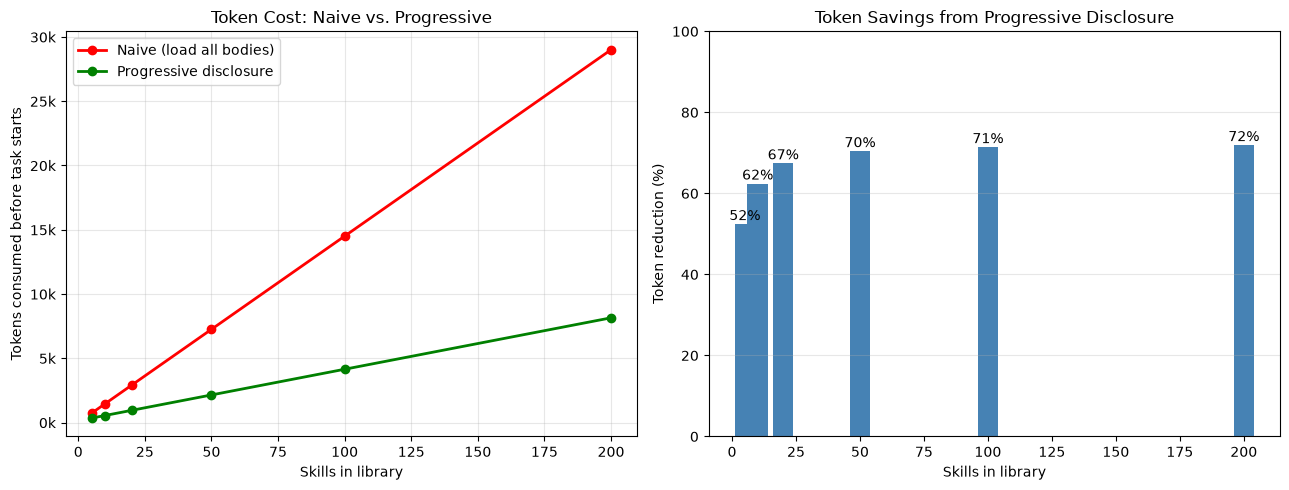

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute token cost
axes[0].plot(library_sizes, naive_costs, "r-o", linewidth=2, label="Naive (load all bodies)")
axes[0].plot(library_sizes, progressive_costs, "g-o", linewidth=2, label="Progressive disclosure")
axes[0].set_xlabel("Skills in library")
axes[0].set_ylabel("Tokens consumed before task starts")
axes[0].set_title("Token Cost: Naive vs. Progressive")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# Right: % reduction
reductions = [(n - p) / n * 100 for n, p in zip(naive_costs, progressive_costs)]
axes[1].bar(library_sizes, reductions, color="steelblue", width=8)
axes[1].set_xlabel("Skills in library")
axes[1].set_ylabel("Token reduction (%)")
axes[1].set_title("Token Savings from Progressive Disclosure")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis="y")
for bar, pct in zip(axes[1].patches, reductions):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{pct:.0f}%",
        ha="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

The savings compound as the library grows. At 10 skills the reduction is already dramatic; at 100 skills it's near-total. Critically, the progressive cost grows almost flat - adding skills to the library barely increases the per-query token cost because the index remains cheap and only one body ever loads.

## Putting the three tiers together
We now compose the three tiers into a single end-to-end flow. Rather than wrapping everything in a heavyweight loader object, we keep it lean: one small helper assembles the final context, and one orchestration function walks a query through routing, activation, and on-demand resource loading - reusing the tier functions already defined above. This mirrors how a skill-aware agent sits at the entry point of a request, turning a raw user query into a ready-to-use context while paying only for what each task actually touches.

In [12]:
def assemble_skill_context(skill: SkillMetadata, body: str, resources: dict[str, str]) -> str:
    """Compose the system prompt from an activated skill: Tier 2 body + any Tier 3 resources.

    Args:
        skill: The routed skill's Tier 1 metadata record.
        body: The loaded SKILL.md body (Tier 2).
        resources: Mapping of resource path -> content for files pulled in on demand (Tier 3).
    """
    # A one-line banner tells the model which skill governs this turn, then the body
    parts = [f"Active skill: {skill.name} v{skill.version}\n", body]
    # Append each on-demand resource under a clear delimiter so its origin stays attributable
    for path, content in resources.items():
        parts.append(f"\n--- Resource: {path} ---\n{content}")
    return "\n".join(parts)

The helper keeps context assembly explicit and inspectable:
- **Header first** - an `Active skill: <name> v<version>` banner signals which skill is in force for the turn.
- **Body then resources** - the Tier 2 instruction body is followed by any Tier 3 files, each fenced under a `--- Resource: <path> ---` delimiter so the model can attribute what it is reading.
- **Resources are optional** - when nothing was loaded, the prompt is simply the banner plus the body, so a simple task pays nothing for files it never opened.

With context assembly handled, the orchestration function ties the tiers into a single call. It routes against the cheap metadata index, and only on a match does it load the one selected body; it then pulls in just the resources the caller signals before assembling the prompt and invoking the model. If nothing matches, it falls back to the bare model so an off-topic question never pays for skill machinery at all. Notice it calls the same `route_with_llm`, `load_skill_body`, and `load_resource` functions from earlier - the pipeline adds orchestration, not new logic.

In [13]:
def run_progressive_pipeline(query: str, resources_needed: list[str] | None = None):
    """Walk a query through all three tiers and return the activated context plus the answer.

    Returns (context | None, response_text). context is None when no skill matched.
    """
    print(f"Query: {query[:60]}...")

    # Tier 1 — route using ONLY the cheap metadata index (no body loaded yet)
    skill = route_with_llm(query, SKILL_INDEX)
    if skill is None:
        # Nothing matched: answer with the base model, paying zero skill tokens
        print("[T1] no skill matched — using base model")
        return None, llm.invoke([HumanMessage(content=query)]).content
    print(f"[T1] routed to: {skill.name}")

    # Tier 2 — now that one skill is selected, load exactly that body
    body = load_skill_body(skill)
    print(f"[T2] body loaded: {count_tokens(body)} tokens")

    # Tier 3 — pull in only the resources this task actually cites
    resources: dict[str, str] = {}
    for rpath in (resources_needed or []):
        content, tok = load_resource(skill.name, rpath)
        resources[rpath] = content
        print(f"[T3] resource loaded: {rpath} ({tok} tokens)")

    # Assemble the layered context and answer the query with it
    system_prompt = assemble_skill_context(skill, body, resources)
    response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=query)])
    return {"skill": skill, "body": body, "resources": resources}, response.content

The function reads as a straight three-tier descent, each tier gated on the previous one:
- **Tier 1 is the gate** - if routing returns nothing, the function exits immediately on the base model and no skill content is ever loaded.
- **Tier 2 loads exactly one body** - only the routed skill's instructions enter context, never the whole library.
- **Tier 3 is caller-driven** - resources load only when their paths are passed in, simulating an agent that reaches a step citing a file mid-task.
- **The return value** carries the assembled pieces so the next cell can account for the token cost precisely.

To see the full descent in action, we send a real code-review request and tell the pipeline that the task will reach for the review checklist partway through. The trace printed by each tier shows the order things load - route, then body, then the single resource - before the final answer is produced from that assembled context.

In [14]:
SAMPLE_CODE_FOR_REVIEW = """
def calculate_discount(price, discount_pct):
    return price - (price * discount_pct)  # bug: 20% passed as 20 not 0.2

def login(username, password):
    query = f"SELECT * FROM users WHERE name='{username}' AND pass='{password}'"
    return db.execute(query)  # SQL injection vulnerability
"""

# Run a code-review task that also needs a checklist resource mid-execution (Tier 3)
context, result = run_progressive_pipeline(
    query=f"Please review this code:\n{SAMPLE_CODE_FOR_REVIEW}",
    resources_needed=["references/review-checklist.md"],
)

print("\nAgent response:")
print("-" * 55)
print(result)

Query: Please review this code:

def calculate_discount(price, disc...
[T1] routed to: code-review
[T2] body loaded: 144 tokens
[T3] resource loaded: references/review-checklist.md (151 tokens)

Agent response:
-------------------------------------------------------
CRITICAL ISSUES:
1. Line 2: The discount percentage is expected to be a decimal (e.g., 0.2 for 20%), but the function does not handle this correctly. 
   - Fix: Change the calculation to `return price - (price * (discount_pct / 100))` to correctly apply the discount percentage.

2. Line 5: The SQL query is constructed using string interpolation, which exposes the code to SQL injection vulnerabilities.
   - Fix: Use parameterized queries to prevent SQL injection, e.g., `query = "SELECT * FROM users WHERE name=%s AND pass=%s"` and then pass the parameters to the `db.execute()` method.

MAJOR ISSUES:
1. None identified.

MINOR ISSUES:
1. Line 1: The comment indicating a bug is not clear and could be misleading. It should be mo

The trace confirms the lazy, layered loading: routing chose `code-review` from metadata alone, a single body entered context, and the checklist resource loaded only because the call requested it. To make the payoff concrete, the final cell tallies exactly what this one query cost, tier by tier, against the naive baseline of loading every body upfront.

In [15]:
# Tally exactly what this query paid, tier by tier
if context:
    index_cost = sum(count_tokens(s.to_index_string()) for s in SKILL_INDEX)   # Tier 1
    body_cost = count_tokens(context["body"])                                   # Tier 2
    resource_cost = sum(count_tokens(v) for v in context["resources"].values())# Tier 3
    total = index_cost + body_cost + resource_cost

    # Baseline: a naive agent that loads every skill body before doing anything
    naive_equivalent = sum(count_tokens(b) for b in SAMPLE_SKILL_BODIES.values())

    print("Token accounting for this query:")
    print(f"  Tier 1 - Index ({len(SKILL_INDEX)} skills):        {index_cost:>6} tokens")
    print(f"  Tier 2 - Skill body ({context['skill'].name}):     {body_cost:>6} tokens")
    print(f"  Tier 3 - Resources loaded:           {resource_cost:>6} tokens")
    print(f"  {'-'*42}")
    print(f"  Total (progressive):                 {total:>6} tokens")
    print(f"  Naive (all bodies upfront):          {naive_equivalent:>6} tokens")
    print(f"  Saved by progressive disclosure:     {naive_equivalent - total:>6} tokens ({(1 - total/naive_equivalent)*100:.0f}%)")

Token accounting for this query:
  Tier 1 - Index (5 skills):           204 tokens
  Tier 2 - Skill body (code-review):        144 tokens
  Tier 3 - Resources loaded:              151 tokens
  ------------------------------------------
  Total (progressive):                    499 tokens
  Naive (all bodies upfront):             727 tokens
  Saved by progressive disclosure:        228 tokens (31%)


- **Naive loading doesn't scale.** Loading all skill bodies upfront consumes tokens proportional to library size. At 20+ skills this crowds out the actual task reasoning.
- **Two routing strategies complement each other.** Embedding similarity is fast and free; LLM-based routing is more accurate for ambiguous or paraphrased queries. Use embeddings for high-traffic agents, LLM routing as fallback.